# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** [Naufal Fakhri]
- **Email:** [naufaalfakhri@gmail.com]
- **ID Dicoding:** [Naufal Fakhri]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

- **Pertanyaan 1: Bagaimana perkembangan jumlah pesanan dan total nilai penjualan secara bulanan selama periode transaksi yang tersedia dalam dataset, serta periode mana yang menunjukkan performa penjualan tertinggi dan terendah?** 
  
- **Pertanyaan 2: Bagaimana hubungan antara durasi pengiriman pesanan dan tingkat kepuasan pelanggan berdasarkan review score selama periode transaksi yang tersedia dalam dataset?** 

## Import Semua Packages/Library yang Digunakan

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## Data Wrangling

### Gathering Data

#### Load Dataset

Pada tahap ini, seluruh dataset yang disediakan untuk analisis dimuat ke dalam DataFrame menggunakan library Pandas. Dataset terdiri dari data pelanggan, geolocation, pesanan, item pesanan, pembayaran, ulasan, produk, kategori produk, dan seller.

Data akan diperiksa terlebih dahulu secara terpisah sebelum dilakukan proses penggabungan pada tahap berikutnya.

In [4]:
# Memuat dataset
customers_df = pd.read_csv("data/customers_dataset.csv")
geolocation_df = pd.read_csv("data/geolocation_dataset.csv")
order_items_df = pd.read_csv("data/order_items_dataset.csv")
order_payments_df = pd.read_csv("data/order_payments_dataset.csv")
order_reviews_df = pd.read_csv("data/order_reviews_dataset.csv")
orders_df = pd.read_csv("data/orders_dataset.csv")
category_translation_df = pd.read_csv("data/product_category_name_translation.csv")
products_df = pd.read_csv("data/products_dataset.csv")
sellers_df = pd.read_csv("data/sellers_dataset.csv")

In [6]:
# Menampilkan ukuran setiap dataset
datasets = {
    "Customers": customers_df,
    "Geolocation": geolocation_df,
    "Order Items": order_items_df,
    "Order Payments": order_payments_df,
    "Order Reviews": order_reviews_df,
    "Orders": orders_df,
    "Category Translation": category_translation_df,
    "Products": products_df,
    "Sellers": sellers_df
}

for name, df in datasets.items():
    print(f"{name:20} : {df.shape[0]:,} baris × {df.shape[1]} kolom")

Customers            : 99,441 baris × 5 kolom
Geolocation          : 1,000,163 baris × 5 kolom
Order Items          : 112,650 baris × 7 kolom
Order Payments       : 103,886 baris × 5 kolom
Order Reviews        : 99,224 baris × 7 kolom
Orders               : 99,441 baris × 8 kolom
Category Translation : 71 baris × 2 kolom
Products             : 32,951 baris × 9 kolom
Sellers              : 3,095 baris × 4 kolom


### Assessing Data

#### Identifying Data Quality Problems

In [8]:
# Mengecek missing value dan duplicate pada setiap dataset
for name, df in datasets.items():
    print(f"{name}")
    
    # Missing values
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    
    if len(missing) > 0:
        print("\nMissing Value:")
        print(missing)
    else:
        print("\nMissing Value: Tidak ditemukan")
    
    # Duplicate
    duplicate = df.duplicated().sum()
    print(f"\nDuplicate rows: {duplicate:,}")

Customers

Missing Value: Tidak ditemukan

Duplicate rows: 0
Geolocation

Missing Value: Tidak ditemukan

Duplicate rows: 261,831
Order Items

Missing Value: Tidak ditemukan

Duplicate rows: 0
Order Payments

Missing Value: Tidak ditemukan

Duplicate rows: 0
Order Reviews

Missing Value:
review_comment_title      87656
review_comment_message    58247
dtype: int64

Duplicate rows: 0
Orders

Missing Value:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

Duplicate rows: 0
Category Translation

Missing Value: Tidak ditemukan

Duplicate rows: 0
Products

Missing Value:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Duplicate rows: 0
Sellers

Missing Value: Tidak ditemukan

Dupl

**Steps to Take:**

- Memeriksa missing value pada setiap dataset untuk mengetahui kolom yang memiliki data kosong.
- Memeriksa duplicate rows untuk memastikan tidak terdapat data yang tercatat lebih dari satu kali.
- Memeriksa tipe data setiap kolom, terutama kolom tanggal dan numerik, agar sesuai dengan kebutuhan analisis.
- Menentukan tindakan cleaning berdasarkan permasalahan yang benar-benar ditemukan dari hasil assessment.

**Insight:**

- Ditemukan missing value pada beberapa kolom tertentu yang perlu ditangani pada tahap Cleaning Data.
- Pemeriksaan duplicate digunakan untuk memastikan setiap baris data tidak tercatat secara berulang.
- Beberapa kolom bertipe datetime masih perlu dikonversi ke format tanggal/waktu agar dapat digunakan untuk analisis berbasis waktu.

### Cleaning Data

#### Fixing Data Quality Problems

Pada tahap ini dilakukan proses pembersihan data berdasarkan permasalahan yang ditemukan pada tahap Assessing Data. Proses cleaning meliputi penanganan missing value, duplicate data, serta penyesuaian tipe data apabila diperlukan untuk mendukung proses analisis selanjutnya.

In [9]:
# Menghapus duplicate rows
for name, df in datasets.items():
    before = len(df)
    df.drop_duplicates(inplace=True)
    after = len(df)
    
    print(f"{name}: {before - after:,} duplicate rows removed")

Customers: 0 duplicate rows removed
Geolocation: 261,831 duplicate rows removed
Order Items: 0 duplicate rows removed
Order Payments: 0 duplicate rows removed
Order Reviews: 0 duplicate rows removed
Orders: 0 duplicate rows removed
Category Translation: 0 duplicate rows removed
Products: 0 duplicate rows removed
Sellers: 0 duplicate rows removed


**Insight:**

- Ditemukan sebanyak **261.831 baris duplikat** pada dataset `Geolocation`, sedangkan dataset lainnya tidak memiliki baris duplikat.
- Baris duplikat pada dataset `Geolocation` telah dihapus karena merupakan data yang tercatat secara identik dan berpotensi menyebabkan perhitungan atau visualisasi geografis menjadi bias.

## Exploratory Data Analysis (EDA)

### Exploratory Data Analysis

Pada tahap Exploratory Data Analysis (EDA), dilakukan eksplorasi terhadap data yang telah melalui proses cleaning untuk memperoleh informasi yang dapat menjawab pertanyaan bisnis. Analisis dibagi menjadi dua fokus, yaitu performa penjualan dan hubungan antara durasi pengiriman dengan tingkat kepuasan pelanggan.

**Insight:**

- Analisis EDA digunakan untuk melihat pola performa penjualan berdasarkan jumlah pesanan dan total nilai penjualan secara bulanan.
- Analisis juga digunakan untuk melihat pola hubungan antara durasi pengiriman dengan tingkat kepuasan pelanggan berdasarkan review score.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana perkembangan jumlah pesanan dan total nilai penjualan secara bulanan selama periode transaksi yang tersedia dalam dataset, serta periode mana yang menunjukkan performa penjualan tertinggi dan terendah?

In [12]:
# Menyiapkan data untuk analisis performa penjualan
sales_df = orders_df[
    ["order_id", "order_status", "order_purchase_timestamp"]
].merge(
    order_items_df[
        ["order_id", "price", "freight_value"]
    ],
    on="order_id",
    how="inner"
)

# Mengubah timestamp menjadi datetime
sales_df["order_purchase_timestamp"] = pd.to_datetime(
    sales_df["order_purchase_timestamp"]
)

# Membuat periode bulanan
sales_df["year_month"] = sales_df["order_purchase_timestamp"].dt.to_period("M")

# Agregasi penjualan bulanan
monthly_sales = sales_df.groupby("year_month").agg(
    total_orders=("order_id", "nunique"),
    total_sales=("price", "sum")
).reset_index()

monthly_sales

,year_month,total_orders,total_sales
0,2016-09,3,267.36
1,2016-10,308,49507.66
2,2016-12,1,10.90
3,2017-01,789,120312.87
4,2017-02,1733,247303.02
5,2017-03,2641,374344.30
6,2017-04,2391,359927.23
7,2017-05,3660,506071.14
8,2017-06,3217,433038.60
9,2017-07,3969,498031.48


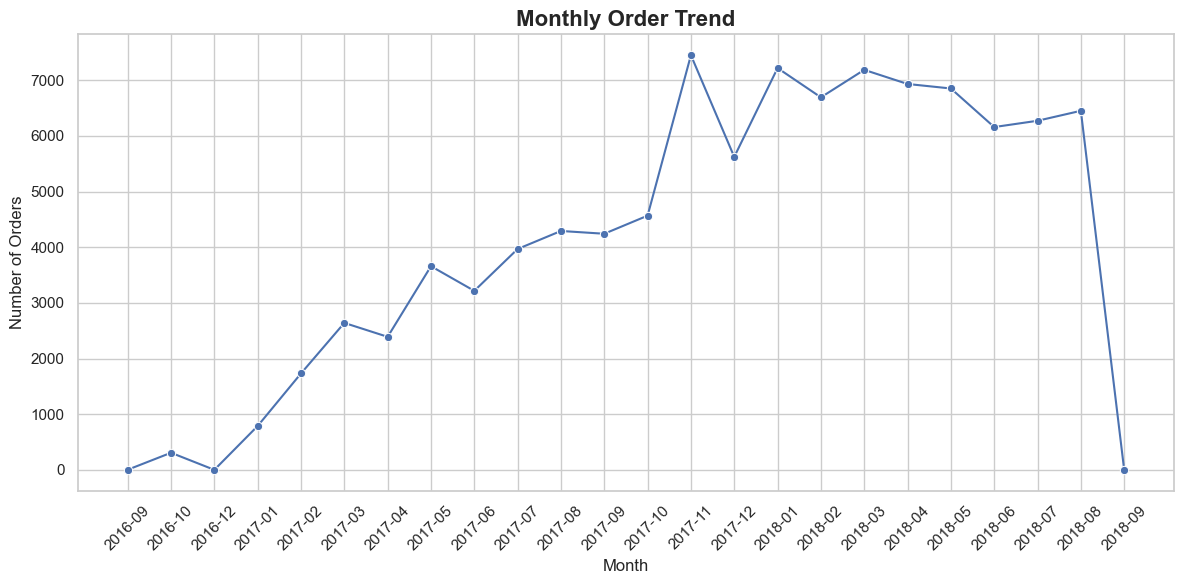

In [13]:
# Menyiapkan data untuk visualisasi
visual_sales = monthly_sales.copy()

visual_sales["year_month"] = visual_sales["year_month"].astype(str)

# Visualisasi jumlah pesanan per bulan
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=visual_sales,
    x="year_month",
    y="total_orders",
    marker="o"
)

plt.title("Monthly Order Trend", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Pertanyaan 2: Bagaimana hubungan antara durasi pengiriman pesanan dan tingkat kepuasan pelanggan berdasarkan review score selama periode transaksi yang tersedia dalam dataset?

In [16]:
# Menyiapkan data pesanan dan review
delivery_review_df = orders_df[
    [
        "order_id",
        "order_status",
        "order_purchase_timestamp",
        "order_delivered_customer_date"
    ]
].merge(
    order_reviews_df[
        ["order_id", "review_score"]
    ],
    on="order_id",
    how="inner"
)

# Mengubah kolom tanggal menjadi datetime
delivery_review_df["order_purchase_timestamp"] = pd.to_datetime(
    delivery_review_df["order_purchase_timestamp"],
    errors="coerce"
)

delivery_review_df["order_delivered_customer_date"] = pd.to_datetime(
    delivery_review_df["order_delivered_customer_date"],
    errors="coerce"
)

# Menggunakan hanya pesanan yang berhasil dikirim
delivery_review_df = delivery_review_df[
    (delivery_review_df["order_status"] == "delivered") &
    (delivery_review_df["order_delivered_customer_date"].notna())
].copy()

# Menghitung durasi pengiriman dalam hari
delivery_review_df["delivery_days"] = (
    delivery_review_df["order_delivered_customer_date"]
    - delivery_review_df["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

delivery_review_df.head()

,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,review_score,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,4,8.436574
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,4,13.782037
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,5,9.394213
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,5,13.208750
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,5,2.873877


In [19]:
# Membuat kategori durasi pengiriman
delivery_review_df["delivery_category"] = pd.cut(
    delivery_review_df["delivery_days"],
    bins=[-np.inf, 3, 7, 14, np.inf],
    labels=[
        "Fast (≤3 days)",
        "Normal (4–7 days)",
        "Slow (8–14 days)",
        "Very Slow (>14 days)"
    ]
)

delivery_summary = delivery_review_df.groupby(
    "delivery_category",
    observed=False
).agg(
    average_review_score=("review_score", "mean"),
    total_orders=("order_id", "nunique")
).reset_index()

delivery_summary

,delivery_category,average_review_score,total_orders
0,Fast (≤3 days),4.483354,4733
1,Normal (4–7 days),4.403306,21200
2,Slow (8–14 days),4.311533,39997
3,Very Slow (>14 days),3.720622,29894


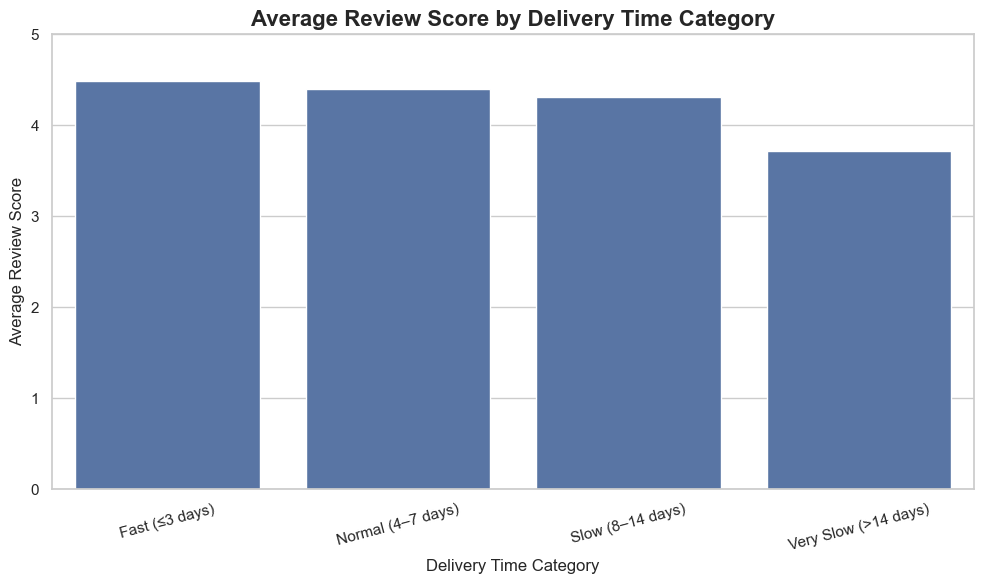

In [20]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=delivery_summary,
    x="delivery_category",
    y="average_review_score"
)

plt.title(
    "Average Review Score by Delivery Time Category",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Delivery Time Category")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

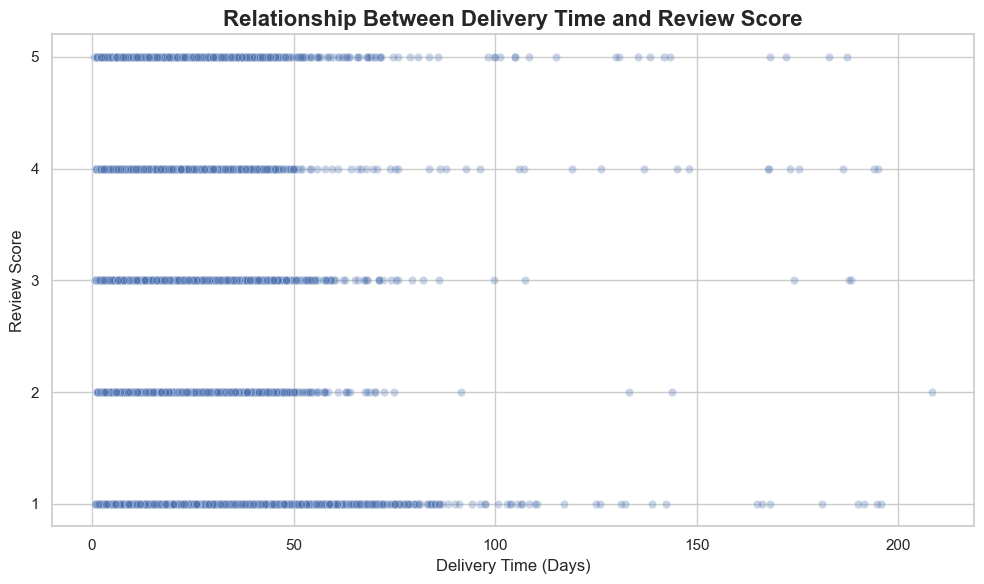

In [21]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=delivery_review_df,
    x="delivery_days",
    y="review_score",
    alpha=0.3
)

plt.title(
    "Relationship Between Delivery Time and Review Score",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Delivery Time (Days)")
plt.ylabel("Review Score")
plt.yticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.show()

**Insight:**

- Terdapat perbedaan tingkat kepuasan pelanggan berdasarkan kategori durasi pengiriman. Kategori dengan durasi pengiriman lebih cepat memiliki rata-rata review score yang lebih tinggi dibandingkan kategori dengan durasi pengiriman yang lebih lama.
- Pola tersebut menunjukkan bahwa durasi pengiriman berkaitan dengan tingkat kepuasan pelanggan. Pesanan dengan waktu pengiriman yang lebih lama cenderung memperoleh review score yang lebih rendah.
- Hal ini menunjukkan bahwa peningkatan kecepatan dan ketepatan proses pengiriman dapat menjadi salah satu aspek yang perlu diperhatikan untuk meningkatkan pengalaman pelanggan.

## Analisis Lanjutan (Opsional)

### RFM Analysis

RFM Analysis digunakan untuk mengidentifikasi karakteristik pelanggan berdasarkan tiga indikator utama, yaitu Recency, Frequency, dan Monetary. Analisis ini bertujuan untuk mengetahui perilaku pembelian pelanggan dan mengidentifikasi segmen pelanggan yang dapat menjadi prioritas dalam strategi retensi dan pemasaran.

In [22]:
# Menyiapkan data untuk RFM Analysis

rfm_df = orders_df[
    [
        "order_id",
        "customer_id",
        "order_purchase_timestamp",
        "order_status"
    ]
].merge(
    order_payments_df[
        ["order_id", "payment_value"]
    ],
    on="order_id",
    how="inner"
)

# Mengubah timestamp menjadi datetime
rfm_df["order_purchase_timestamp"] = pd.to_datetime(
    rfm_df["order_purchase_timestamp"],
    errors="coerce"
)

# Menggunakan order yang berhasil diselesaikan
rfm_df = rfm_df[
    rfm_df["order_status"] == "delivered"
].copy()

rfm_df.head()

,order_id,customer_id,order_purchase_timestamp,order_status,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,delivered,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,delivered,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,delivered,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,delivered,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,delivered,179.12


In [23]:
# Menentukan reference date untuk perhitungan Recency
reference_date = (
    rfm_df["order_purchase_timestamp"].max()
    + pd.Timedelta(days=1)
)

print("Reference Date:", reference_date)

Reference Date: 2018-08-30 15:00:37


In [24]:
# Menghitung RFM setiap customer

rfm = rfm_df.groupby("customer_id").agg(
    Recency=(
        "order_purchase_timestamp",
        lambda x: (reference_date - x.max()).days
    ),
    Frequency=(
        "order_id",
        "nunique"
    ),
    Monetary=(
        "payment_value",
        "sum"
    )
).reset_index()

rfm.head()

,customer_id,Recency,Frequency,Monetary
0,00012a2ce6f8dcda20d059ce98491703,288,1,114.74
1,000161a058600d5901f007fab4c27140,410,1,67.41
2,0001fd6190edaaf884bcaf3d49edf079,548,1,195.42
3,0002414f95344307404f0ace7a26f1d5,379,1,179.35
4,000379cdec625522490c315e70c7a9fb,150,1,107.01


In [25]:
# Membuat RFM Score

rfm["R_score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    q=5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["F_score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["M_score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["RFM_score"] = (
    rfm["R_score"]
    + rfm["F_score"]
    + rfm["M_score"]
)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
0,00012a2ce6f8dcda20d059ce98491703,288,1,114.74,2,1,3,6
1,000161a058600d5901f007fab4c27140,410,1,67.41,1,1,2,4
2,0001fd6190edaaf884bcaf3d49edf079,548,1,195.42,1,1,4,6
3,0002414f95344307404f0ace7a26f1d5,379,1,179.35,2,1,4,7
4,000379cdec625522490c315e70c7a9fb,150,1,107.01,4,1,3,8


In [26]:
def segment_customer(row):
    if row["RFM_score"] >= 13:
        return "Champions"
    elif row["RFM_score"] >= 10:
        return "Loyal Customers"
    elif row["RFM_score"] >= 7:
        return "Potential Loyalists"
    elif row["RFM_score"] >= 5:
        return "At Risk"
    else:
        return "Lost Customers"

rfm["customer_segment"] = rfm.apply(
    segment_customer,
    axis=1
)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,customer_segment
0,00012a2ce6f8dcda20d059ce98491703,288,1,114.74,2,1,3,6,At Risk
1,000161a058600d5901f007fab4c27140,410,1,67.41,1,1,2,4,Lost Customers
2,0001fd6190edaaf884bcaf3d49edf079,548,1,195.42,1,1,4,6,At Risk
3,0002414f95344307404f0ace7a26f1d5,379,1,179.35,2,1,4,7,Potential Loyalists
4,000379cdec625522490c315e70c7a9fb,150,1,107.01,4,1,3,8,Potential Loyalists


In [27]:
segment_summary = rfm.groupby(
    "customer_segment"
).agg(
    customer_count=("customer_id", "nunique"),
    average_recency=("Recency", "mean"),
    average_frequency=("Frequency", "mean"),
    average_monetary=("Monetary", "mean")
).reset_index()

segment_summary

,customer_segment,customer_count,average_recency,average_frequency,average_monetary
0,At Risk,12630,357.252811,1.0,67.784734
1,Champions,7838,90.822149,1.0,311.747800
2,Lost Customers,3079,438.705099,1.0,46.643540
3,Loyal Customers,33085,176.405833,1.0,209.032771
4,Potential Loyalists,39845,269.910604,1.0,127.077341


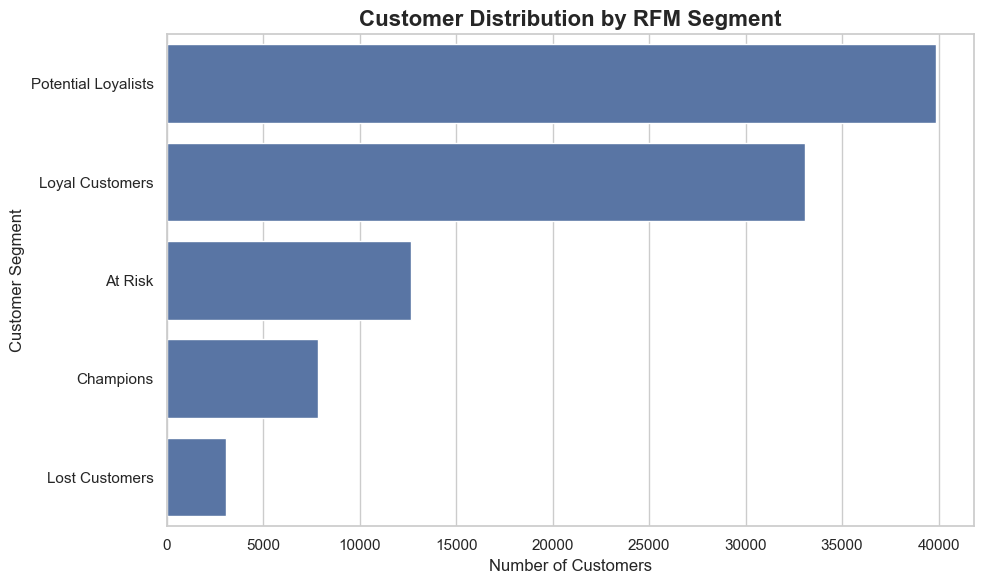

In [28]:
plt.figure(figsize=(10, 6))

segment_order = (
    rfm["customer_segment"]
    .value_counts()
    .index
)

sns.countplot(
    data=rfm,
    y="customer_segment",
    order=segment_order
)

plt.title(
    "Customer Distribution by RFM Segment",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

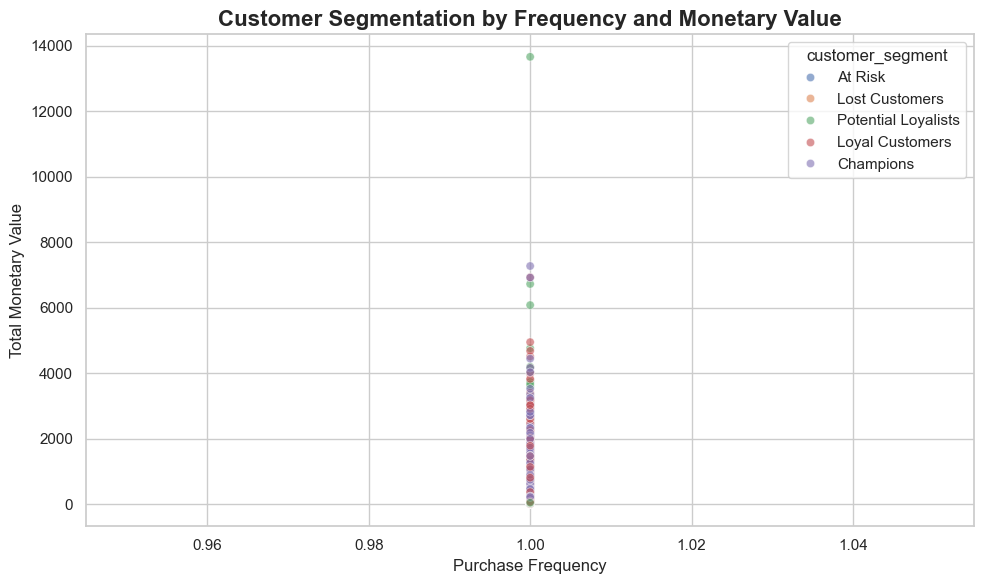

In [29]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="customer_segment",
    alpha=0.6
)

plt.title(
    "Customer Segmentation by Frequency and Monetary Value",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Purchase Frequency")
plt.ylabel("Total Monetary Value")

plt.tight_layout()
plt.show()

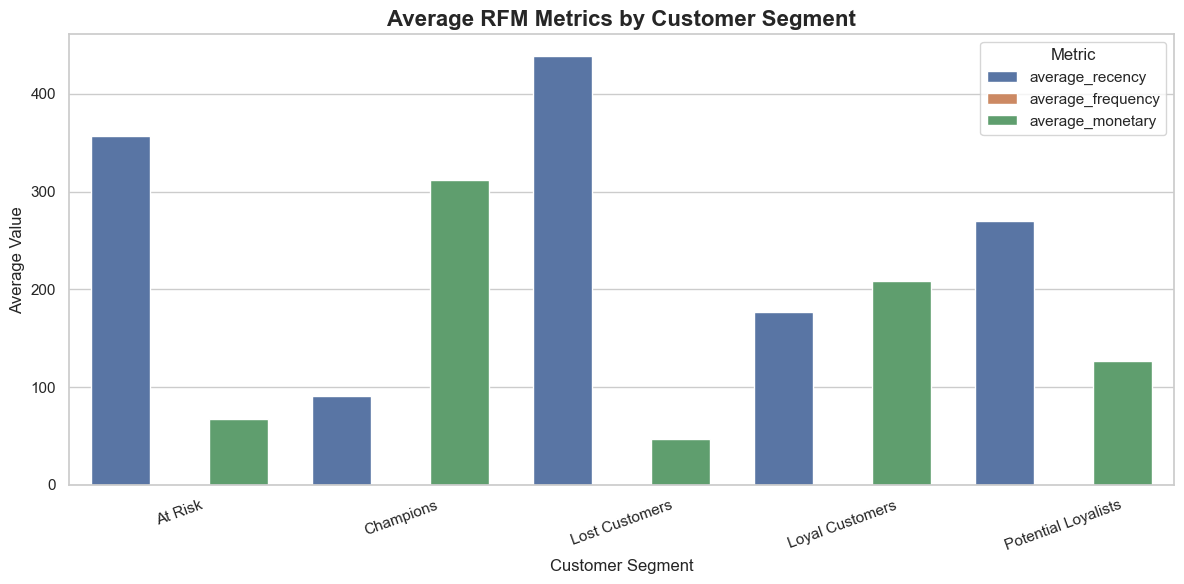

In [30]:
rfm_melted = segment_summary.melt(
    id_vars="customer_segment",
    value_vars=[
        "average_recency",
        "average_frequency",
        "average_monetary"
    ],
    var_name="Metric",
    value_name="Average Value"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=rfm_melted,
    x="customer_segment",
    y="Average Value",
    hue="Metric"
)

plt.title(
    "Average RFM Metrics by Customer Segment",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Customer Segment")
plt.ylabel("Average Value")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

**Insight:**

- RFM Analysis menunjukkan bahwa pelanggan memiliki karakteristik perilaku pembelian yang berbeda berdasarkan Recency, Frequency, dan Monetary.
- Segmentasi pelanggan membantu mengidentifikasi kelompok pelanggan berdasarkan tingkat aktivitas pembelian, frekuensi transaksi, dan total nilai pengeluaran.
- Pelanggan dengan Frequency dan Monetary yang tinggi merupakan kelompok yang memiliki nilai bisnis lebih besar sehingga dapat menjadi prioritas dalam strategi retensi pelanggan.
- Pelanggan dengan Recency yang tinggi perlu mendapat perhatian karena menunjukkan bahwa pelanggan tersebut sudah cukup lama tidak melakukan pembelian dan berpotensi mengalami penurunan engagement.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Performa penjualan menunjukkan tren peningkatan dari awal periode pengamatan hingga 2017, dengan jumlah pesanan dan total nilai penjualan mencapai salah satu titik tertinggi pada November 2017, yaitu sebanyak **7.451 pesanan** dengan total nilai penjualan sebesar **1,010,271.37**. Hal ini menunjukkan bahwa November 2017 merupakan salah satu periode dengan performa penjualan yang sangat kuat.

- **Conclusion pertanyaan 2:** Terdapat perbedaan tingkat kepuasan pelanggan berdasarkan durasi pengiriman. Hasil analisis menunjukkan bahwa kategori durasi pengiriman yang lebih cepat cenderung memiliki tingkat review yang lebih baik dibandingkan kategori pengiriman yang lebih lama. Hal ini menunjukkan bahwa durasi pengiriman merupakan aspek yang perlu diperhatikan dalam meningkatkan pengalaman pelanggan.

**Rekomendasi Action Item:**

1. **Optimasi strategi penjualan**
   - Identifikasi dan evaluasi strategi yang diterapkan pada periode dengan performa penjualan tinggi untuk dijadikan referensi dalam perencanaan kampanye penjualan berikutnya.

2. **Perbaikan performa logistik**
   - Memprioritaskan evaluasi proses pengiriman pada kategori dengan durasi pengiriman paling lama untuk mengurangi potensi penurunan kepuasan pelanggan.

3. **Customer retention berbasis RFM**
   - Memberikan program loyalitas atau penawaran khusus kepada pelanggan dengan Frequency dan Monetary tinggi.
   - Menjalankan kampanye reaktivasi kepada pelanggan dengan Recency tinggi agar pelanggan kembali melakukan transaksi.

In [31]:
# Export data untuk dashboard
dashboard_data = sales_df.copy()

dashboard_data["year_month"] = dashboard_data["year_month"].astype(str)

dashboard_data.to_csv(
    "dashboard/main_data.csv",
    index=False
)

print("main_data.csv berhasil dibuat!")

main_data.csv berhasil dibuat!
